In [1]:
import pandas as pd

In [58]:
tabela_usinas = pd.read_parquet("tabela_usinas.parquet")

### Calcula índices de flexibilidade para cada subsistema
- O cálculo é feito para cada subsistema do SIN, considerando 1, 2, 4 e 6 horas de rampa.
- O cálculo considera as fontes solar e eólica de forma negativa (demanda de flexibilidade)
- Enquanto considera outras fontes são consideradas de forma positiva (oferta de flexibilidade).

In [ ]:
filtro_sistema = tabela_usinas['id_subsistema'] == 'S'
filtro_REN = tabela_usinas['nom_tipousina'].isin(['EOLIELÉTRICA', 'FOTOVOLTAICA'])
filtro_oferta = filtro_sistema & ~filtro_REN
filtro_demanda = filtro_sistema & filtro_REN
for horas in [1, 2, 4, 6]:
    cap_instalada = tabela_usinas.loc[filtro_sistema, 'P max'].sum()
    flex_oferta = (tabela_usinas.loc[filtro_oferta, "Ind Flex Up P" + str(horas)] * tabela_usinas.loc[filtro_oferta, 'P max']).sum()
    flex_demanda = (-1*tabela_usinas.loc[filtro_demanda, "Ind Flex Down P" + str(horas)] * tabela_usinas.loc[filtro_demanda, 'P max']).sum()
    flex_NE = (flex_oferta + flex_demanda)/cap_instalada
    print(f"NFI do Nordeste é de: {flex_NE:.2f} ")

NFI do Nordeste é de: 0.37 
NFI do Nordeste é de: 0.41 
NFI do Nordeste é de: 0.40 
NFI do Nordeste é de: 0.39 


### Análise com anos de entrada das usinas

In [3]:
capacidade = pd.read_parquet("capacidade_geracao.parquet")

In [ ]:
# Procura automaticamente a data de entrada em operação das usinas
for usina in tabela_usinas["nom_usina"]:
    mask_capacidade = capacidade["nom_usina"].str.upper() == usina.upper()
    if mask_capacidade.any():
        data_entrada = capacidade.loc[mask_capacidade, "dat_entradaoperacao"].values[0]
        tabela_usinas.loc[tabela_usinas["nom_usina"] == usina, "dat_entradaoperacao"] = data_entrada

In [ ]:
# Premissa: MMGD entrada em 2018 e PCT/PCH entrada em 2015
usinas_datas = {
    "BBF Baliza": "2024-04-11",
    "Alto Jatapu": "1994-01-01",
    "Conj. Paulino Neves": "2017-11-07",
    "Cristiano Rocha": "2007-12-18",
    "Distrito": "1990-12-31",
    "Conj. Arinos 2 500 kV": "2024-04-30",
    "Conj. Janaúba": "2022-07-30",
    "PQU BOEBA FOTOV MMGD": "2017-01-01",
    "PQU BSCAL FOTOV MMGD": "2017-01-01",
    "PQU BSSBA FOTOV MMGD": "2017-01-01",
    "PQU BSSES FOTOV MMGD": "2017-01-01",
    "PQU CECE EOL - CARGA GLOBAL": "2018-01-01",
    "PQU CECE FOTOV - CARGA GLOBAL": "2018-01-01",
    "PQU CECE FOTOV MMGD": "2018-01-01",
    "PQU PRPR EOL - CARGA GLOBAL": "2018-01-01",
    "PQU PRPR FOTOV MMGD": "2018-01-01",
    "PQU PRPR HID - CARGA GLOBAL": "2015-01-01",
    "PQU PRPR TERM - CARGA GLOBAL": "2015-01-01",
    "PQU RSRS EOL - CARGA GLOBAL": "2018-01-01",
    "PQU RSRS FOTOV MMGD": "2018-01-01",
    "PQU RSRS HID - CARGA GLOBAL": "2015-01-01",
    "PQU RSRS TERM - CARGA GLOBAL": "2015-01-01",
    "PQU MGMG FOTOV - CARGA GLOBAL": "2018-01-01",
    "PQU MGMG FOTOV MMGD": "2018-01-01",
    "PQU MGMG HID - CARGA GLOBAL": "2015-01-01",
    "PQU MGMG TERM - CARGA GLOBAL": "2015-01-01",
    "PQU MTMT FOTOV - CARGA GLOBAL": "2018-01-01",
    "PQU MTMT FOTOV MMGD": "2018-01-01",
    "PQU MTMT HID - CARGA GLOBAL": "2015-01-01",
    "PQU MTMT TERM - CARGA GLOBAL": "2018-01-01",
    "PQU SPSP FOTOV - CARGA GLOBAL": "2018-01-01",
    "PQU SPSP FOTOV MMGD": "2018-01-01",
    "PQU SPSP HID - CARGA GLOBAL": "2015-01-01",
    "PQU SPSP TERM - CARGA GLOBAL": "2015-01-01"
}


In [19]:
# Premissa: MMGD entrada em 2018 e Eol entrada em 2016
mask_mmgd_sem_data = tabela_usinas["nom_usina"].str.contains("MMGD") & tabela_usinas["dat_entradaoperacao"].isna()
tabela_usinas.loc[mask_mmgd_sem_data, "dat_entradaoperacao"] = "2018-01-01"
mask_fotov_cargaglobal = tabela_usinas["nom_usina"].str.contains("FOTOV - CARGA GLOBAL") & tabela_usinas["dat_entradaoperacao"].isna()
tabela_usinas.loc[mask_fotov_cargaglobal, "dat_entradaoperacao"] = "2018-01-01"
mask_eol_cece_cargaglobal = tabela_usinas["nom_usina"].str.contains("EOL - CARGA GLOBAL") & tabela_usinas["dat_entradaoperacao"].isna()
tabela_usinas.loc[mask_eol_cece_cargaglobal, "dat_entradaoperacao"] = "2016-01-01"

In [ ]:
# Salva premissas anteriores de MMGD, PEQ e alguns complexos.
for usina, data in usinas_datas.items():
    tabela_usinas.loc[tabela_usinas["nom_usina"] == usina, "dat_entradaoperacao"] = data

In [59]:
# Premissa rápida: todas as outras usinas entram entre 2008 e 2024, distribuindo linearmente
mask_sem_data = tabela_usinas["dat_entradaoperacao"].isna()
num_sem_data = mask_sem_data.sum()
if num_sem_data > 0:
    datas = pd.date_range(start="2013-01-01", end="2024-12-31", periods=num_sem_data)
    tabela_usinas.loc[mask_sem_data, "dat_entradaoperacao"] = datas.strftime("%Y-%m-%d")

### Flexibilidade ao longo do tempo

In [60]:
anos = range(1990, 2026, 5) # De 1990 até 2025 de 5 em 5 anos
sistemas = ['N', 'S', 'SE', 'NE']
resultados = []
for ano in anos:
    for sistema in sistemas:
        filtro_sistema = tabela_usinas['id_subsistema'] == sistema
        filtro_REN = tabela_usinas['nom_tipousina'].isin(['EOLIELÉTRICA', 'FOTOVOLTAICA'])
        filtro_anos = pd.to_datetime(tabela_usinas['dat_entradaoperacao']).dt.year <= ano
        filtro_oferta = filtro_sistema & ~filtro_REN & filtro_anos
        filtro_demanda = filtro_sistema & filtro_REN & filtro_anos
        for horas in [1, 2, 4, 6]:
            cap_instalada = tabela_usinas.loc[filtro_sistema, 'P max'].sum()
            flex_oferta = (tabela_usinas.loc[filtro_oferta, "Ind Flex Up P" + str(horas)] * tabela_usinas.loc[filtro_oferta, 'P max']).sum()
            flex_demanda = (-1 * tabela_usinas.loc[filtro_demanda, "Ind Flex Down P" + str(horas)] * tabela_usinas.loc[filtro_demanda, 'P max']).sum()
            flex_sistema = (flex_oferta + flex_demanda) / cap_instalada if cap_instalada > 0 else float('nan')
            resultados.append({"sistema": sistema, "horas": horas, "ano": ano, "NFI": flex_sistema})
            # print(f"NFI do subsistema {sistema} para {horas}h é de: {flex_sistema:.2f}")

resultado = pd.DataFrame(resultados)

In [ ]:
# Converte a coluna de data para o tipo númerico de dia.
tabela_usinas["dat_entradaoperacao"] = pd.to_datetime(tabela_usinas["dat_entradaoperacao"], errors='coerce')

In [27]:
tabela_usinas.to_parquet("tabela_usinas.parquet", index=False)

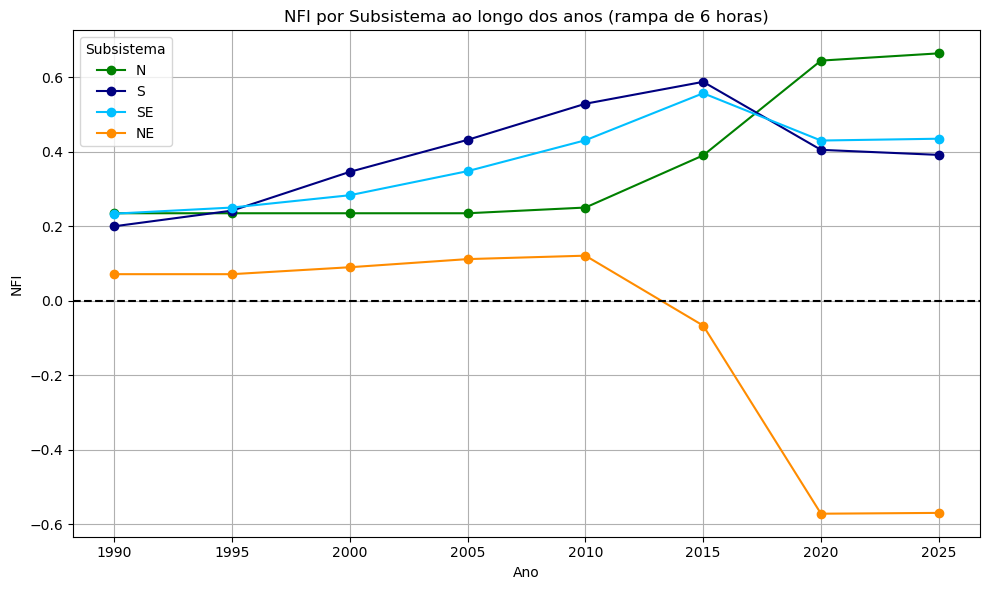

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
passo_horas = 6

cores = ['green', 'navy', 'deepskyblue', '#FF8C00']  # '#FF8C00' é laranja escuro
for idx, sistema in enumerate(sistemas):
    dados = resultado[(resultado['sistema'] == sistema) & (resultado['horas'] == passo_horas)]
    plt.plot(dados['ano'], dados['NFI'], marker='o', label=sistema, color=cores[idx])

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Ano')
plt.ylabel('NFI')
plt.title('NFI por Subsistema ao longo dos anos (rampa de ' + str(passo_horas) + ' horas)')
plt.legend(title='Subsistema')
plt.grid(True)
plt.tight_layout()
plt.show()
